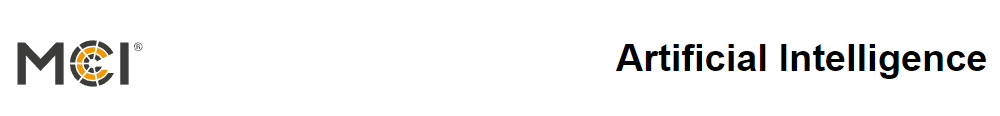

---

# 01 a PCA on Breast Cancer

As this is the introduction to PCA, we want to understand what the PCA is doing to our data and how we can use it.
Principal Component Analysis (PCA) is a dimensionality-reduction technique that transforms correlated variables into a smaller set of uncorrelated components that capture maximal variance, typically via eigen-decomposition of the covariance matrix or singular value decomposition of the centered data matrix. By projecting data onto the leading eigenvectors, PCA denoises high-dimensional measurements while preserving structure critical for interpretation and downstream modeling. In medicine, PCA helps integrate multimodal patient data (e.g., genomics, imaging, labs) to reveal latent phenotypes, reduce overfitting in predictive models, and visualize disease subtypes; in radiology and pathology, it supports feature extraction from images and accelerates pipelines prior to classification. In rehabilitation, PCA isolates dominant movement synergies from kinematic and electromyography (EMG) signals to assess motor control, track recovery trajectories, and tailor interventions by identifying compensatory patterns post-stroke or injury. In sports science, it distills wearable sensor streams (accelerometry, IMU, force-plate data) into key performance indicators, enabling athlete profiling, load monitoring, and technique optimization while filtering noise and redundancy. Across these domains, PCA improves interpretability, reduces measurement burden, and enhances model stability, though care is needed to standardize variables, check linearity and stationarity assumptions, and validate that retained components remain clinically or biomechanically meaningful.
As always we want to learn on a given example, so we want to use the breast cancer dataset from scikit-learn do a PCA on it.

As always we start with importing all the relevant packages

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1 The Data

Details on the dataset can be found under https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic. 

In [7]:
# Load Breast Cancer Wisconsin dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')  # 0 = malignant, 1 = benign

X.head(), y.value_counts()

(   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
 0        17.99         10.38          122.80     1001.0          0.11840   
 1        20.57         17.77          132.90     1326.0          0.08474   
 2        19.69         21.25          130.00     1203.0          0.10960   
 3        11.42         20.38           77.58      386.1          0.14250   
 4        20.29         14.34          135.10     1297.0          0.10030   
 
    mean compactness  mean concavity  mean concave points  mean symmetry  \
 0           0.27760          0.3001              0.14710         0.2419   
 1           0.07864          0.0869              0.07017         0.1812   
 2           0.15990          0.1974              0.12790         0.2069   
 3           0.28390          0.2414              0.10520         0.2597   
 4           0.13280          0.1980              0.10430         0.1809   
 
    mean fractal dimension  ...  worst radius  worst texture  worst perimeter 

As you can see, we have 30 features as input with the following meaning:

* radius (mean of distances from center to points on the perimeter)
* texture (standard deviation of gray-scale values)
* perimeter
* area
* smoothness (local variation in radius lengths)
* compactness (perimeter^2 / area - 1.0)
* concavity (severity of concave portions of the contour)
* concave points (number of concave portions of the contour)
* symmetry 
* fractal dimension ("coastline approximation" - 1)

The features above describe the shape, size and some other features of a potentially malignant cell nucleaus.

# 2. Prepare for and do PCA

A PCA needs the data standardized. So we can use a scaler to sclae the data and the trasform it for the PCA.

In [8]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA (keep enough components to explain ~95% variance)
pca = PCA(n_components=None, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

print(f"Components to reach 95% variance: {(cum_explained < 0.95).sum() + 1}")

Components to reach 95% variance: 10


Just by looking at the result, we can describe 95% of the variance in the outcome with only 10 principle components. That means, we are losing just a little bit of information but in return only need 10 PCs instead of 30 features. Data can be heavily reduced due to the PCA (30 --> 10).

# 3. Plots and Analysis PCA

As we have done the PCA now, we want to know what the PCA relied on, how strong the PCs individually contribute and we want that in a visual way.

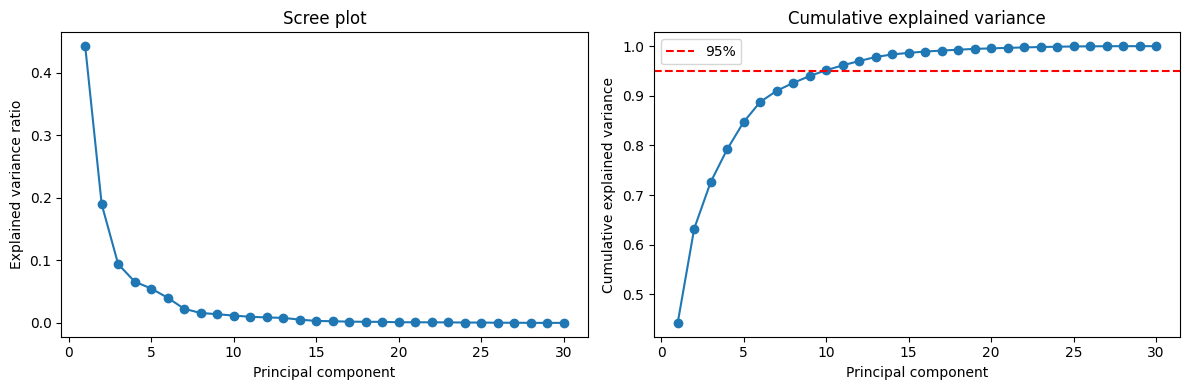

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

# Scree plot
ax[0].plot(np.arange(1, len(explained)+1), explained, marker='o')
ax[0].set_xlabel('Principal component')
ax[0].set_ylabel('Explained variance ratio')
ax[0].set_title('Scree plot')

# Cumulative explained variance
ax[1].plot(np.arange(1, len(cum_explained)+1), cum_explained, marker='o')
ax[1].axhline(0.95, color='red', linestyle='--', label='95%')
ax[1].set_xlabel('Principal component')
ax[1].set_ylabel('Cumulative explained variance')
ax[1].set_title('Cumulative explained variance')
ax[1].legend()

plt.tight_layout()
plt.show()

As we can see, 95% is reached at 10 PCs but we can go even lower if we want to. Let's have a closer look at PC 1 and 2.

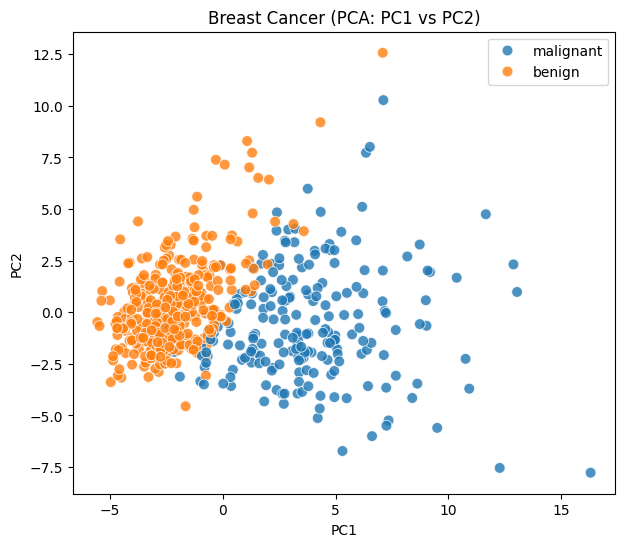

In [10]:
pc_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'target': y.map({0: 'malignant', 1: 'benign'})
})

plt.figure(figsize=(7,6))
sns.scatterplot(data=pc_df, x='PC1', y='PC2', hue='target', alpha=0.8, s=60)
plt.title('Breast Cancer (PCA: PC1 vs PC2)')
plt.legend()
plt.show()

As it seems, having a relatively high PC1 supports the classification towards the malignant label. So let's have a closer look to it as we want to understand what that means.


Top contributors to PC1:
mean concave points     0.260854
mean concavity          0.258400
worst concave points    0.250886
mean compactness        0.239285
worst perimeter         0.236640
worst concavity         0.228768
worst radius            0.227997
mean perimeter          0.227537
worst area              0.224871
mean area               0.220995
Name: PC1, dtype: float64

Top contributors to PC2:
mean fractal dimension     0.366575
fractal dimension error    0.280092
worst fractal dimension    0.275339
mean radius                0.233857
compactness error          0.232716
mean area                  0.231077
worst radius               0.219866
worst area                 0.219352
mean perimeter             0.215181
smoothness error           0.204430
Name: PC2, dtype: float64


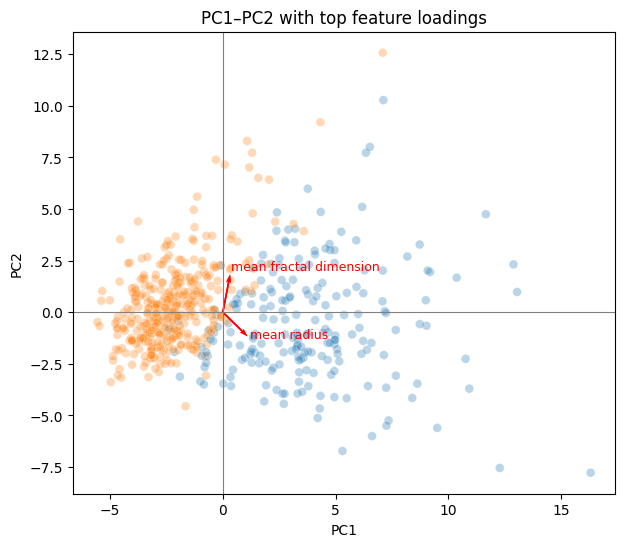

In [17]:
# Loadings: columns=features, rows=PCs
loadings = pd.DataFrame(pca.components_, columns=X.columns, index=[f'PC{i+1}' for i in range(pca.components_.shape[0])])

# Show top features contributing to PC1 and PC2
for pc in ['PC1', 'PC2']:
    print(f"\nTop contributors to {pc}:")
    print(loadings.loc[pc].abs().sort_values(ascending=False).head(10))

# Simple biplot-like overlay (arrows for top features)
top_features = loadings.loc[['PC1','PC2']].T
top_features['mag'] = np.sqrt(top_features['PC1']**2 + top_features['PC2']**2)
topk = top_features.sort_values('mag', ascending=False).head(2)

plt.figure(figsize=(7,6))
sns.scatterplot(data=pc_df, x='PC1', y='PC2', hue='target', alpha=0.3, s=40, legend=False)
origin = np.array([[0,0],[0,0]])
for feat, row in topk.iterrows():
    plt.quiver(*origin, row['PC1']*5, row['PC2']*5, angles='xy', scale_units='xy', scale=1, color='red', width=0.003)
    plt.text(row['PC1']*5*1.1, row['PC2']*5*1.1, feat, color='red', fontsize=9)
plt.title('PC1–PC2 with top feature loadings')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.axhline(0, color='gray', linewidth=0.8)
plt.axvline(0, color='gray', linewidth=0.8)
plt.show()

# 4. Using PCA Reduced Inputs for Downstream Tasks

The PCA reduced the number of features in the dataset. So lets have a look on the concequences of it in a potential downstream task (e.g. classification). In a quick evaluation we can use the cross validation score.

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

k = (cum_explained < 0.95).sum() + 1
pca_k = PCA(n_components=k, random_state=42)
X_k = pca_k.fit_transform(X_scaled)

clf_with_PCA = LogisticRegression(max_iter=50000)
scores = cross_val_score(clf_with_PCA, X_k, y, cv=5, scoring='roc_auc')
print(f"AUC (5-fold CV) with {k} PCs: mean={scores.mean():.3f}, std={scores.std():.3f}")

clf_with_Full_Data = LogisticRegression(max_iter=50000)
scores = cross_val_score(clf_with_Full_Data, X, y, cv=5, scoring='roc_auc')
print(f"AUC (5-fold CV) with full data: mean={scores.mean():.3f}, std={scores.std():.3f}")

AUC (5-fold CV) with 10 PCs: mean=0.995, std=0.005
AUC (5-fold CV) with full data: mean=0.992, std=0.007


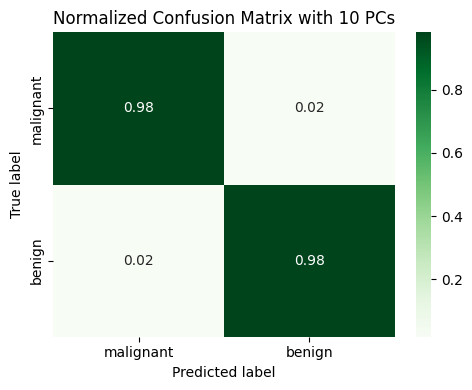

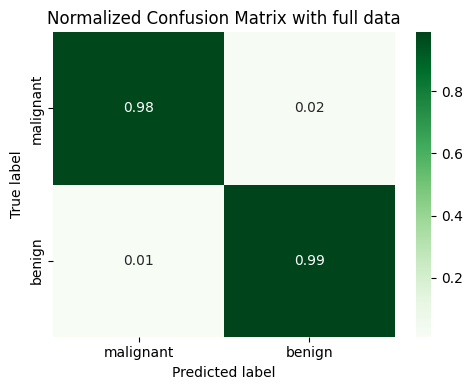

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Use the number of PCs needed to reach ~95% variance (computed earlier)
k = (cum_explained < 0.95).sum() + 1

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

# Fit PCA on training data only, then transform train and test
pca_k = PCA(n_components=k, random_state=42)
X_train_k = pca_k.fit_transform(X_train)
X_test_k  = pca_k.transform(X_test)

# Train a simple classifier
clf_with_PCA = LogisticRegression(max_iter=2000)
clf_with_PCA.fit(X_train_k, y_train)

# Train a simple classifier
clf_without_PCA = LogisticRegression(max_iter=2000)
clf_without_PCA.fit(X_train, y_train)

# Predictions
y_pred_with_PCA = clf_with_PCA.predict(X_test_k)
y_proba_with_PCA = clf_with_PCA.predict_proba(X_test_k)[:, 1]
y_pred_without_PCA = clf_without_PCA.predict(X_test)
y_proba_without_PCA = clf_without_PCA.predict_proba(X_test)[:, 1]

# Confusion matrix (labels: 0 = malignant, 1 = benign)
cm_with_PCA = confusion_matrix(y_test, y_pred_with_PCA, labels=[0, 1])
cm_without_PCA = confusion_matrix(y_test, y_pred_without_PCA, labels=[0, 1])

# Optional: normalized confusion matrix
cm_norm_with_PCA = cm_with_PCA / cm_with_PCA.sum(axis=1, keepdims=True)
plt.figure(figsize=(5,4))
sns.heatmap(cm_norm_with_PCA, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=['malignant','benign'],
            yticklabels=['malignant','benign'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title(f'Normalized Confusion Matrix with {k} PCs')
plt.tight_layout()
plt.show()

# Optional: normalized confusion matrix
cm_norm_without_PCA = cm_without_PCA / cm_without_PCA.sum(axis=1, keepdims=True)
plt.figure(figsize=(5,4))
sns.heatmap(cm_norm_without_PCA, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=['malignant','benign'],
            yticklabels=['malignant','benign'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title(f'Normalized Confusion Matrix with full data')
plt.tight_layout()
plt.show()